In [220]:
import numpy as np
import pint
import pandas as pd
import matplotlib.pyplot as plt

In [185]:
unit = pint.UnitRegistry()

# Part 1: Calorimeters heat capacity


In [241]:
m = 267 * unit.gram
m1 = 272 * unit.gram
m2 = 279 * unit.gram


T1 = unit.Quantity(22, unit.degree_Celsius).to(unit.kelvin)
T2 = unit.Quantity(65, unit.degree_Celsius).to(unit.kelvin)
T = unit.Quantity(33, unit.degree_Celsius).to(unit.kelvin)

c_w = 4.18 * unit.joule / (unit.gram * unit.kelvin)
c_w_n = 1 * unit.joule / (unit.gram * unit.kelvin)
c_w = {0: c_w,1: c_w_n}[0]
C_k = c_w * (m2*(T2 - T) + m1*(T1 - T)) / ((T - T1))
# C_k = c_w * m1*(T2 - T) / (T2 - T1)
C_manufacturer_calorimeter = float(78) * unit.joule / unit.kelvin
C_manufacturer_calorimeter_uncertainty = 2 * unit.joule / unit.kelvin
# C_manufacturer_calorimeter = C_k
print(f"heat capacity of the calorimeter: {C_k:.2f}")
print(f"manufacturer's heat capacity of the calorimeter: {C_manufacturer_calorimeter:.2f} ± {C_manufacturer_calorimeter_uncertainty:.2f}")

heat capacity of the calorimeter: 2255.68 joule / kelvin
manufacturer's heat capacity of the calorimeter: 78.00 joule / kelvin ± 2.00 joule / kelvin


In [242]:
C_manufacturer_calorimeter_uncertainty

<Quantity(2.0, 'joule / kelvin')>

In [221]:
data1 = pd.read_csv('../DATA/DataPart2.csv')    
data2 = pd.read_csv('../DATA/DataPart3.csv')

# Part 2: Effect of the enviorment on $Cu$

### $$ \Delta Q = (c_w m_w + C) \Delta T $$
### $$ \frac{d\Delta Q_{env}}{dt} \rightarrow \text{ The heat flowing from the enviorment to the calorimeter}$$ 




In [222]:

magnitude = lambda x: x.magnitude if isinstance(x, pint.Quantity) else x
tounit = lambda x: lambda y: y.to(x)

In [223]:
data1["t(min)"] = [t * unit.minute for t in data1["t(min)"]]
data1["T(K)"] = [T * unit.kelvin for T in data1["T(K)"]]

In [191]:
data1

,t(min),T(K)
0,1 minute,281.6 kelvin
1,2 minute,281.8 kelvin
2,3 minute,282.2 kelvin
3,4 minute,282.4 kelvin
4,5 minute,282.7 kelvin
5,6 minute,282.9 kelvin
6,7 minute,283.0 kelvin
7,8 minute,283.2 kelvin
8,9 minute,283.4 kelvin
9,10 minute,283.5 kelvin


In [224]:
T_0 = float(281) * unit.kelvin
delta_symbol = "Δ"
mw  = float(218) * unit.gram
T_0.magnitude

281.0

In [225]:

data1[f"{delta_symbol}T"] = [round(T - T_0,3) for T in data1["T(K)"]]
data1[f"{delta_symbol}Q"] = [round((mw * c_w + C_manufacturer_calorimeter)* DT,3) for DT in data1[f"{delta_symbol}T"]]
data1


,t(min),T(K),ΔT,ΔQ
0,1 minute,281.6 kelvin,0.6 kelvin,177.6 joule
1,2 minute,281.8 kelvin,0.8 kelvin,236.8 joule
2,3 minute,282.2 kelvin,1.2 kelvin,355.2 joule
3,4 minute,282.4 kelvin,1.4 kelvin,414.4 joule
4,5 minute,282.7 kelvin,1.7 kelvin,503.2 joule
5,6 minute,282.9 kelvin,1.9 kelvin,562.4 joule
6,7 minute,283.0 kelvin,2.0 kelvin,592.0 joule
7,8 minute,283.2 kelvin,2.2 kelvin,651.2 joule
8,9 minute,283.4 kelvin,2.4 kelvin,710.4 joule
9,10 minute,283.5 kelvin,2.5 kelvin,740.0 joule


In [226]:

data1[f"{delta_symbol}T"].map(magnitude)

data1["t(seconds)"] = data1["t(min)"].map(tounit(unit.second))

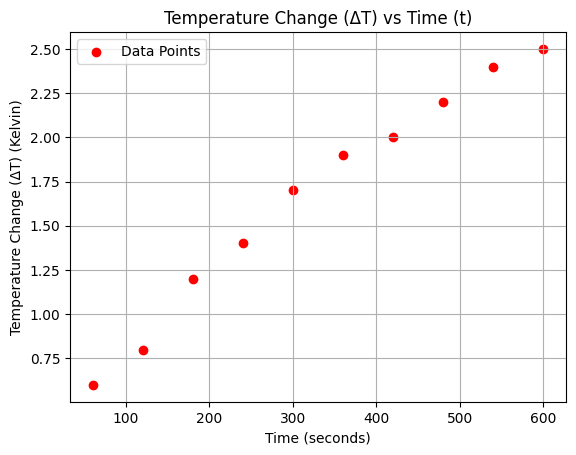

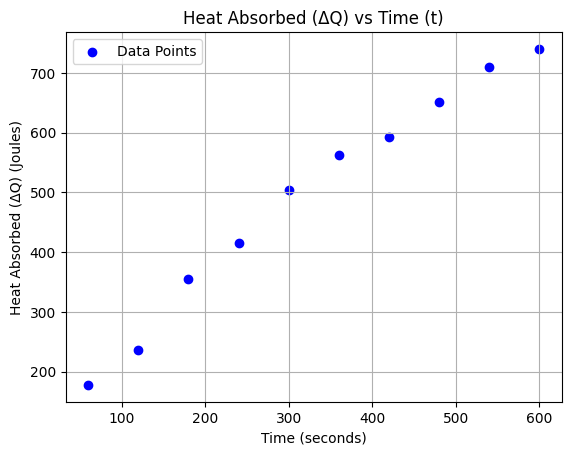

In [195]:
# Plotting Delta T vs t
plt.scatter(data1["t(seconds)"].map(magnitude), data1[f"{delta_symbol}T"].map(magnitude), color='red', label='Data Points')
plt.title('Temperature Change (ΔT) vs Time (t)')
plt.xlabel('Time (seconds)')
plt.ylabel('Temperature Change (ΔT) (Kelvin)')
plt.legend()
plt.grid()
plt.show()

# Plotting ΔQ vs t
plt.scatter(data1["t(seconds)"].map(magnitude), data1[f"{delta_symbol}Q"].map(magnitude), color='blue', label='Data Points')
plt.title('Heat Absorbed (ΔQ) vs Time (t)')
plt.xlabel('Time (seconds)')
plt.ylabel('Heat Absorbed (ΔQ) (Joules)')
plt.legend()
plt.grid()
plt.show()

In [227]:
# Linear fit for ΔT vs t
from scipy.stats import linregress
slope_DT, intercept_DT, r_value_DT, p_value_DT, std_err_DT = linregress(data1["t(seconds)"].map(magnitude), data1[f"{delta_symbol}T"].map(magnitude))
print(f"Linear fit for ΔT vs t: ΔT = {slope_DT:.4f} * t + {intercept_DT:.4f}, R² = {r_value_DT**2:.4f}")
# Linear fit for ΔQ vs t
slope_Q, intercept_Q, r_value_Q, p_value_Q, std_err_Q = linregress(data1["t(seconds)"].map(magnitude), data1[f"{delta_symbol}Q"].map(magnitude))
print(f"Linear fit for ΔQ vs t: ΔQ = {slope_Q:.4f} * t + {intercept_Q:.4f}, R² = {r_value_Q**2:.4f}")

Linear fit for ΔT vs t: ΔT = 0.0036 * t + 0.4933, R² = 0.9780
Linear fit for ΔQ vs t: ΔQ = 1.0554 * t + 146.0267, R² = 0.9780


In [228]:
dQ_env_dt = slope_Q * unit.joule / unit.second
print(f"Rate of heat loss to environment (dQ_environment/dt): {dQ_env_dt:.4f}")

Rate of heat loss to environment (dQ_environment/dt): 1.0554 joule / second


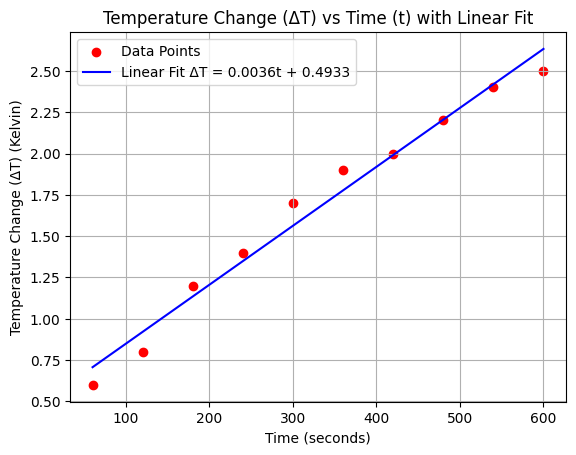

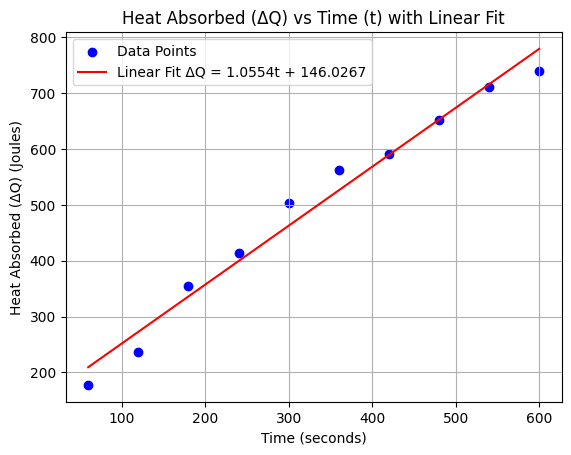

In [198]:
# plot the linear fit for ΔT vs t
plt.scatter(data1["t(seconds)"].map(magnitude), data1[f"{delta_symbol}T"].map(magnitude), color='red', label='Data Points')
plt.plot(data1["t(seconds)"].map(magnitude), slope_DT * data1["t(seconds)"].map(magnitude) + intercept_DT, color='blue', label=f'Linear Fit {delta_symbol}T = {slope_DT:.4f}t + {intercept_DT:.4f}')
plt.title('Temperature Change (ΔT) vs Time (t) with Linear Fit')
plt.xlabel('Time (seconds)')
plt.ylabel('Temperature Change (ΔT) (Kelvin)')
plt.legend()
plt.grid()
plt.savefig('../plots/DeltaT_vs_t_with_fit.png', dpi=300)
plt.show()
# plot the linear fit for ΔQ vs t
plt.scatter(data1["t(seconds)"].map(magnitude), data1[f"{delta_symbol}Q"].map(magnitude), color='blue', label='Data Points')
plt.plot(data1["t(seconds)"].map(magnitude), slope_Q * data1["t(seconds)"].map(magnitude) + intercept_Q, color='red', label=f'Linear Fit {delta_symbol}Q = {slope_Q:.4f}t + {intercept_Q:.4f}')
plt.title('Heat Absorbed (ΔQ) vs Time (t) with Linear Fit')
plt.xlabel('Time (seconds)')
plt.ylabel('Heat Absorbed (ΔQ) (Joules)')
plt.legend()
plt.grid()
plt.savefig('../plots/DeltaQ_vs_t_with_fit.png', dpi=300)
plt.show()

In [229]:
# Export processed Part 2 table (pandas-adjusted columns) for LaTeX
from pathlib import Path

tables_dir = Path("../report/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

data1_export = pd.DataFrame({
    "t_s": data1["t(seconds)"].map(magnitude),
    "T_K": data1["T(K)"].map(magnitude),
    "DeltaT_K": data1[f"{delta_symbol}T"].map(magnitude),
    "DeltaQ_env_J": data1[f"{delta_symbol}Q"].map(magnitude),
})

data1_export.to_csv(tables_dir / "part2_environment_processed.csv", index=False)
data1_export.head()

,t_s,T_K,DeltaT_K,DeltaQ_env_J
0,60,281.6,0.6,177.6
1,120,281.8,0.8,236.8
2,180,282.2,1.2,355.2
3,240,282.4,1.4,414.4
4,300,282.7,1.7,503.2


# Part 3: Determination of thermal conductivity for $Cu$ 

### $$ \frac{dQ}{dt} = \frac{dQ_{total}}{dt} - \frac{dQ_{enviorment}}{dt} =  \lambda A \frac{dT}{dx}$$

In [199]:
data2

,t(min),T(K),DeltaT(rod)(K)
0,1,281.3,4.74
1,2,281.6,6.81
2,3,281.9,9.04
3,4,282.1,10.44
4,5,282.4,11.40
5,6,282.7,11.91
6,7,283.1,12.23
7,8,283.5,12.52
8,9,283.9,12.70
9,10,284.3,12.87


In [230]:
data2["t(min)"] = [t * unit.minute for t in data2["t(min)"]]
data2["T(K)"] = [T * unit.kelvin for T in data2["T(K)"]]
data2["DeltaT(rod)(K)"] = [DT * unit.kelvin for DT in data2["DeltaT(rod)(K)"]]

data2[f"{delta_symbol}T"] = [round(T - T_0,3) for T in data2["T(K)"]]

In [201]:
data2

,t(min),T(K),DeltaT(rod)(K),ΔT
0,1 minute,281.3 kelvin,4.74 kelvin,0.3 kelvin
1,2 minute,281.6 kelvin,6.81 kelvin,0.6 kelvin
2,3 minute,281.9 kelvin,9.04 kelvin,0.9 kelvin
3,4 minute,282.1 kelvin,10.44 kelvin,1.1 kelvin
4,5 minute,282.4 kelvin,11.4 kelvin,1.4 kelvin
5,6 minute,282.7 kelvin,11.91 kelvin,1.7 kelvin
6,7 minute,283.1 kelvin,12.23 kelvin,2.1 kelvin
7,8 minute,283.5 kelvin,12.52 kelvin,2.5 kelvin
8,9 minute,283.9 kelvin,12.7 kelvin,2.9 kelvin
9,10 minute,284.3 kelvin,12.87 kelvin,3.3 kelvin


In [231]:
data2["t(seconds)"] = data2["t(min)"].map(tounit(unit.second))

In [232]:
mw = (634 -267) * unit.gram
data2[f"{delta_symbol}Qtotal"] = [round((mw * c_w + C_manufacturer_calorimeter)* DT,3) for DT in data2[f"{delta_symbol}T"]]

In [233]:
slope_Q_total_t, intercept_Q_total_t, r_value_Q_total_t, p_value_Q_total_t, std_err_Q_total_t = linregress(data2["t(seconds)"].map(magnitude), data2[f"{delta_symbol}Qtotal"].map(magnitude))
print(f"Linear fit for ΔQtotal vs t: ΔQtotal = {slope_Q_total_t:.4f} * t + {intercept_Q_total_t:.4f}, R² = {r_value_Q_total_t**2:.4f}")

Linear fit for ΔQtotal vs t: ΔQtotal = 2.4453 * t + -59.3333, R² = 0.9903


In [234]:
dQtot_dt = slope_Q_total_t * unit.joule / unit.second
print(f"Rate of heat absorption (dQ_total/dt): {dQtot_dt:.4f}")

Rate of heat absorption (dQ_total/dt): 2.4453 joule / second


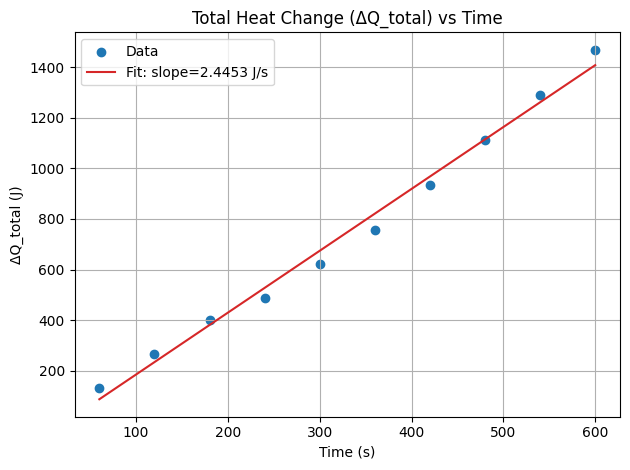

,t_s,T_K,DeltaT_K,DeltaQ_total_J,DeltaT_rod_K
0,60,281.3,0.3,133.5,4.74
1,120,281.6,0.6,267.0,6.81
2,180,281.9,0.9,400.5,9.04
3,240,282.1,1.1,489.5,10.44
4,300,282.4,1.4,623.0,11.40


In [235]:
# Save Part 3 regression figure (ΔQ_total vs t) and export processed table for LaTeX
from pathlib import Path

plots_dir = Path("../plots")
plots_dir.mkdir(parents=True, exist_ok=True)

# Regression plot: ΔQ_total vs t with linear fit
t_s2 = data2["t(seconds)"].map(magnitude)
dQtotal_J = data2[f"{delta_symbol}Qtotal"].map(magnitude)
plt.figure()
plt.scatter(t_s2, dQtotal_J, color="tab:blue", label="Data")
plt.plot(t_s2, slope_Q_total_t * t_s2 + intercept_Q_total_t, color="tab:red", label=f"Fit: slope={slope_Q_total_t:.4f} J/s")
plt.title("Total Heat Change (ΔQ_total) vs Time")
plt.xlabel("Time (s)")
plt.ylabel("ΔQ_total (J)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(plots_dir / "DeltaQtotal_vs_t_with_fit.png", dpi=300)
plt.show()

tables_dir = Path("../report/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

data2_export = pd.DataFrame({
    "t_s": t_s2,
    "T_K": data2["T(K)"].map(magnitude),
    "DeltaT_K": data2[f"{delta_symbol}T"].map(magnitude),
    "DeltaQ_total_J": dQtotal_J,
    "DeltaT_rod_K": data2["DeltaT(rod)(K)"].map(magnitude),
})
data2_export.to_csv(tables_dir / "part3_total_processed.csv", index=False)
data2_export.head()

In [206]:
data2

,t(min),T(K),DeltaT(rod)(K),ΔT,t(seconds),ΔQtotal
0,1 minute,281.3 kelvin,4.74 kelvin,0.3 kelvin,60 second,133.5 joule
1,2 minute,281.6 kelvin,6.81 kelvin,0.6 kelvin,120 second,267.0 joule
2,3 minute,281.9 kelvin,9.04 kelvin,0.9 kelvin,180 second,400.5 joule
3,4 minute,282.1 kelvin,10.44 kelvin,1.1 kelvin,240 second,489.5 joule
4,5 minute,282.4 kelvin,11.4 kelvin,1.4 kelvin,300 second,623.0 joule
5,6 minute,282.7 kelvin,11.91 kelvin,1.7 kelvin,360 second,756.5 joule
6,7 minute,283.1 kelvin,12.23 kelvin,2.1 kelvin,420 second,934.5 joule
7,8 minute,283.5 kelvin,12.52 kelvin,2.5 kelvin,480 second,1112.5 joule
8,9 minute,283.9 kelvin,12.7 kelvin,2.9 kelvin,540 second,1290.5 joule
9,10 minute,284.3 kelvin,12.87 kelvin,3.3 kelvin,600 second,1468.5 joule


In [207]:
slope_DT_t_pt2, intercept_DT_t_pt2, r_value_DT_t_pt2, p_value_DT_t_pt2, std_err_DT_t_pt2 = linregress(data2["t(seconds)"].map(magnitude), data2[f"{delta_symbol}T"].map(magnitude))
print(f"Linear fit for ΔT vs t: ΔT = {slope_DT_t_pt2:.4f} * t + {intercept_DT_t_pt2:.4f}, R² = {r_value_DT_t_pt2**2:.4f}")

Linear fit for ΔT vs t: ΔT = 0.0055 * t + -0.1333, R² = 0.9903


In [236]:
dT = (data2["DeltaT(rod)(K)"].map(magnitude)).mean()
dx = (24.5 * unit.centimeter).to(unit.meter)

print(f"Average ΔT(rod): {dT:.4f} K")
print(f"Probe distance: {dx:.4f} m")

dT_dx = (dT * unit.kelvin) / (dx)
print(f"ΔT/Δx: {dT_dx:.4f}")


Average ΔT(rod): 10.4660 K
Probe distance: 0.2450 meter m
ΔT/Δx: 42.7184 kelvin / meter


In [237]:
r = 2.5 * unit.centimeter
A = 4.91e-4 * unit.meter**2
dQ_dt = dQtot_dt - dQ_env_dt
print(f"Cross sectional area of the rod (A): {A:.4f}")
print(f"Net rate of heat absorption (dQ/dt): {dQ_dt:.4f}")


Cross sectional area of the rod (A): 0.0005 meter ** 2
Net rate of heat absorption (dQ/dt): 1.3898 joule / second


In [238]:
lambda_Cu =  dQ_dt / (A * dT_dx)
lambda_Cu = lambda_Cu.to(unit.watt / (unit.meter * unit.kelvin))
print(f"Thermal conductivity (λ_Cu): {lambda_Cu:.4f}")

Thermal conductivity (λ_Cu): 66.2616 watt / kelvin / meter


In [ ]:
# Radius implied by the cross-sectional area used in this notebook
A_rod = 4.91e-4 * unit.meter**2
r_from_A = (np.sqrt(A_rod / np.pi) * unit.meter).to(unit.centimeter)
r_from_A

<Quantity(1.12978876, 'centimeter')>

# Part 4: Electrical conductivity of $Al$

In [239]:

A = 4.91e-4 * unit.meter**2
l = 0.42 * unit.meter
V = 0.88 * unit.volt
I = 0.393 * unit.ampere
# R = 592 * unit.ohm
R = (V/I).to(unit.ohm)
sigma_Al = l / (R * A)

In [213]:
(V/I).to(unit.ohm)

<Quantity(2.23918575, 'ohm')>

In [219]:
sigma_Al.to(1/(unit.ohm * unit.meter))

<Quantity(382.01259, '1 / ohm / meter')>